folderpath= C:\Users\30960\OneDrive\课题组\NIR\opv\2D\PM6\20220107-622pump-10uw
keylist= ['0ps', '-0.05ps', '0.05ps', '-0.1ps']
folderpath= C:\Users\30960\OneDrive\课题组\NIR\opv\2D\PM6\20220107-622pump-10uw


<IPython.core.display.Javascript object>


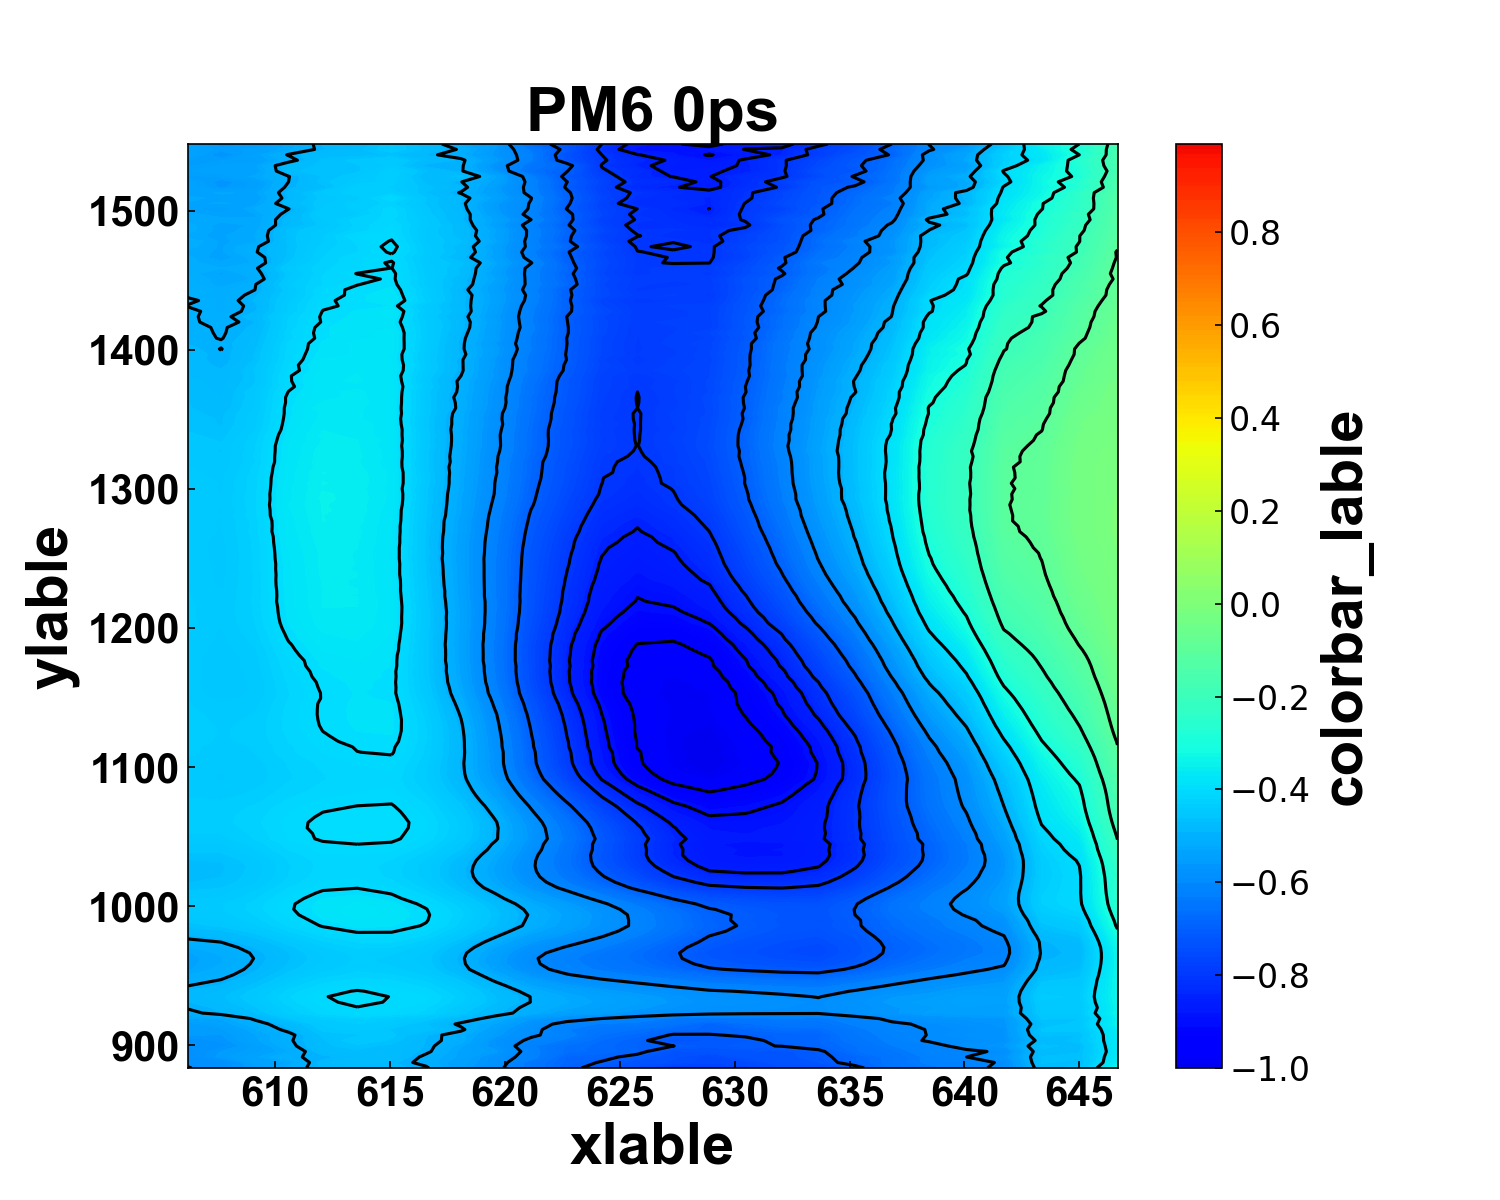

<IPython.core.display.Javascript object>


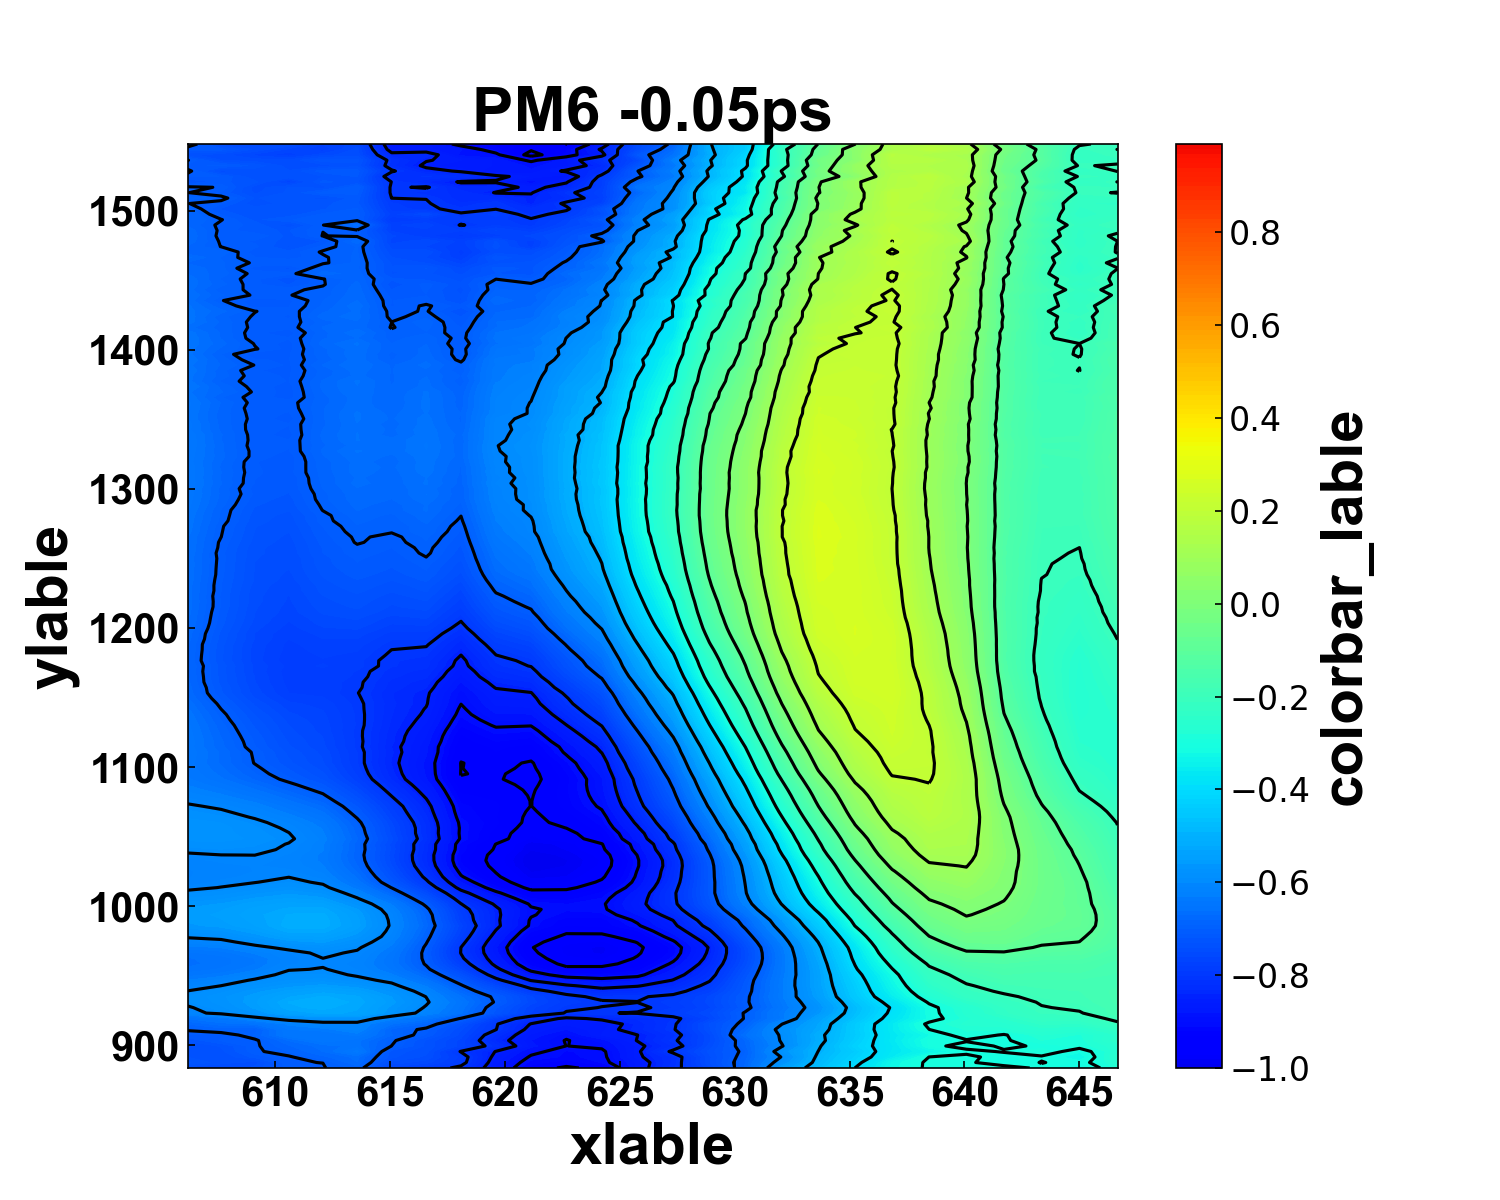

<IPython.core.display.Javascript object>


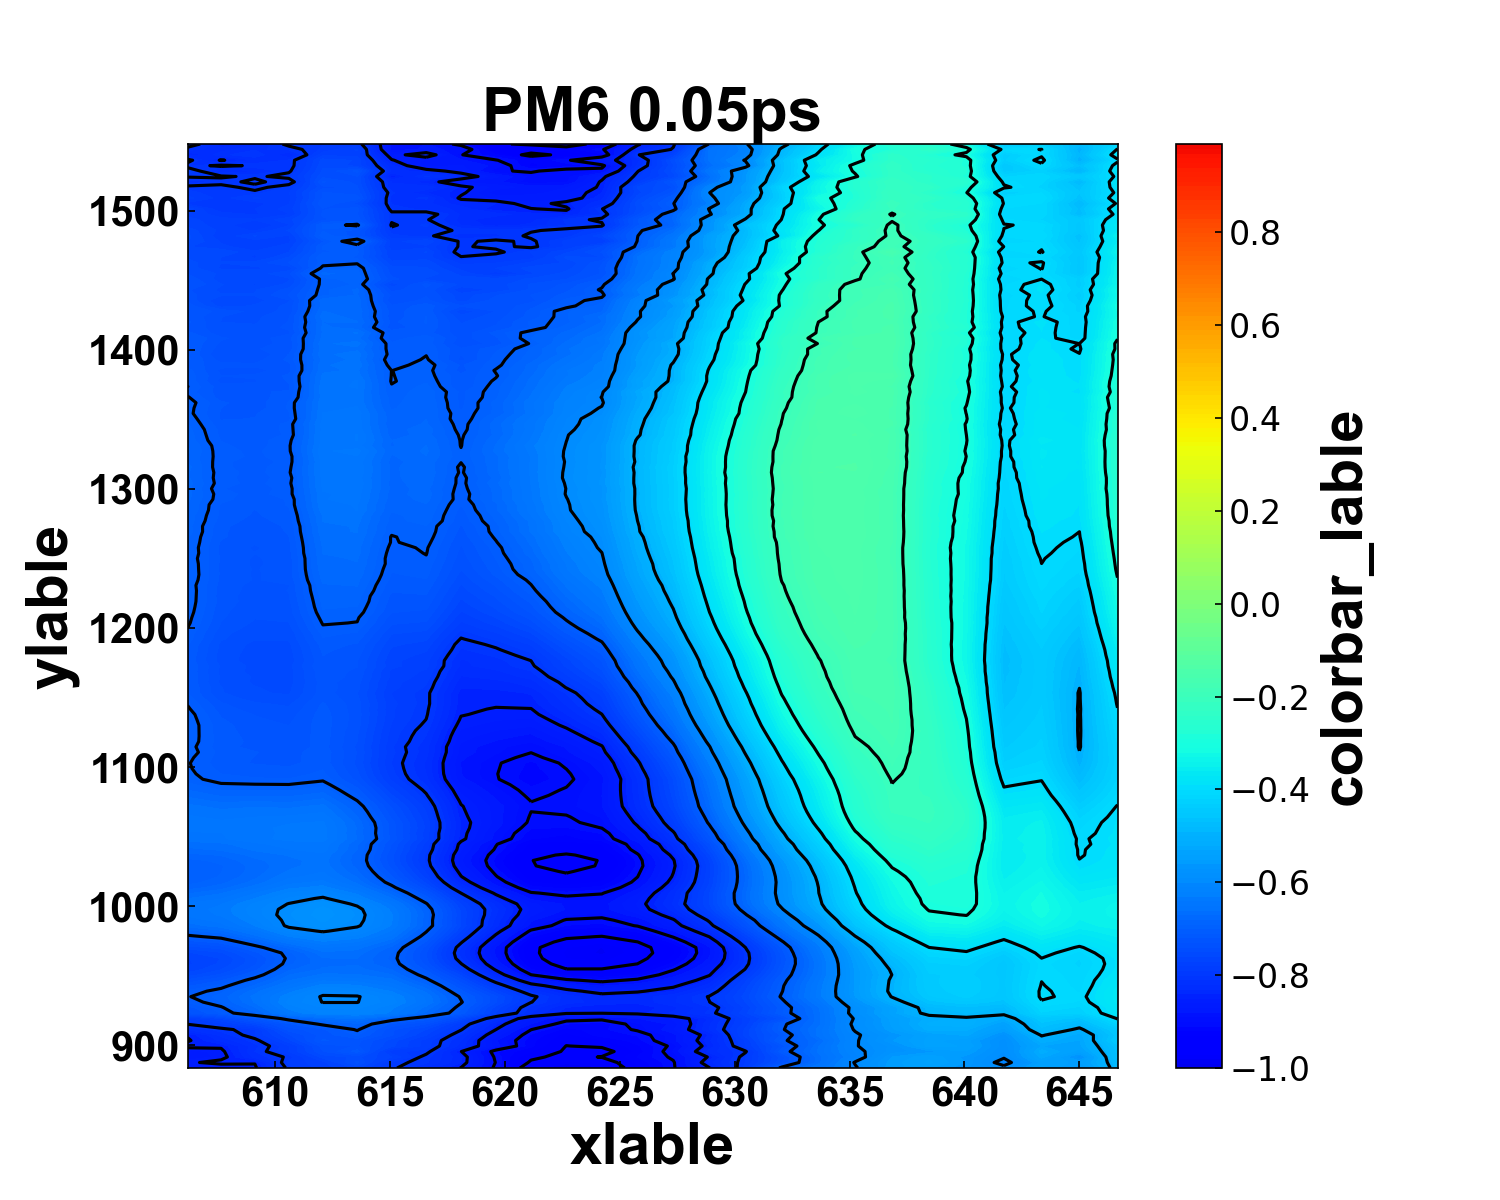

<IPython.core.display.Javascript object>


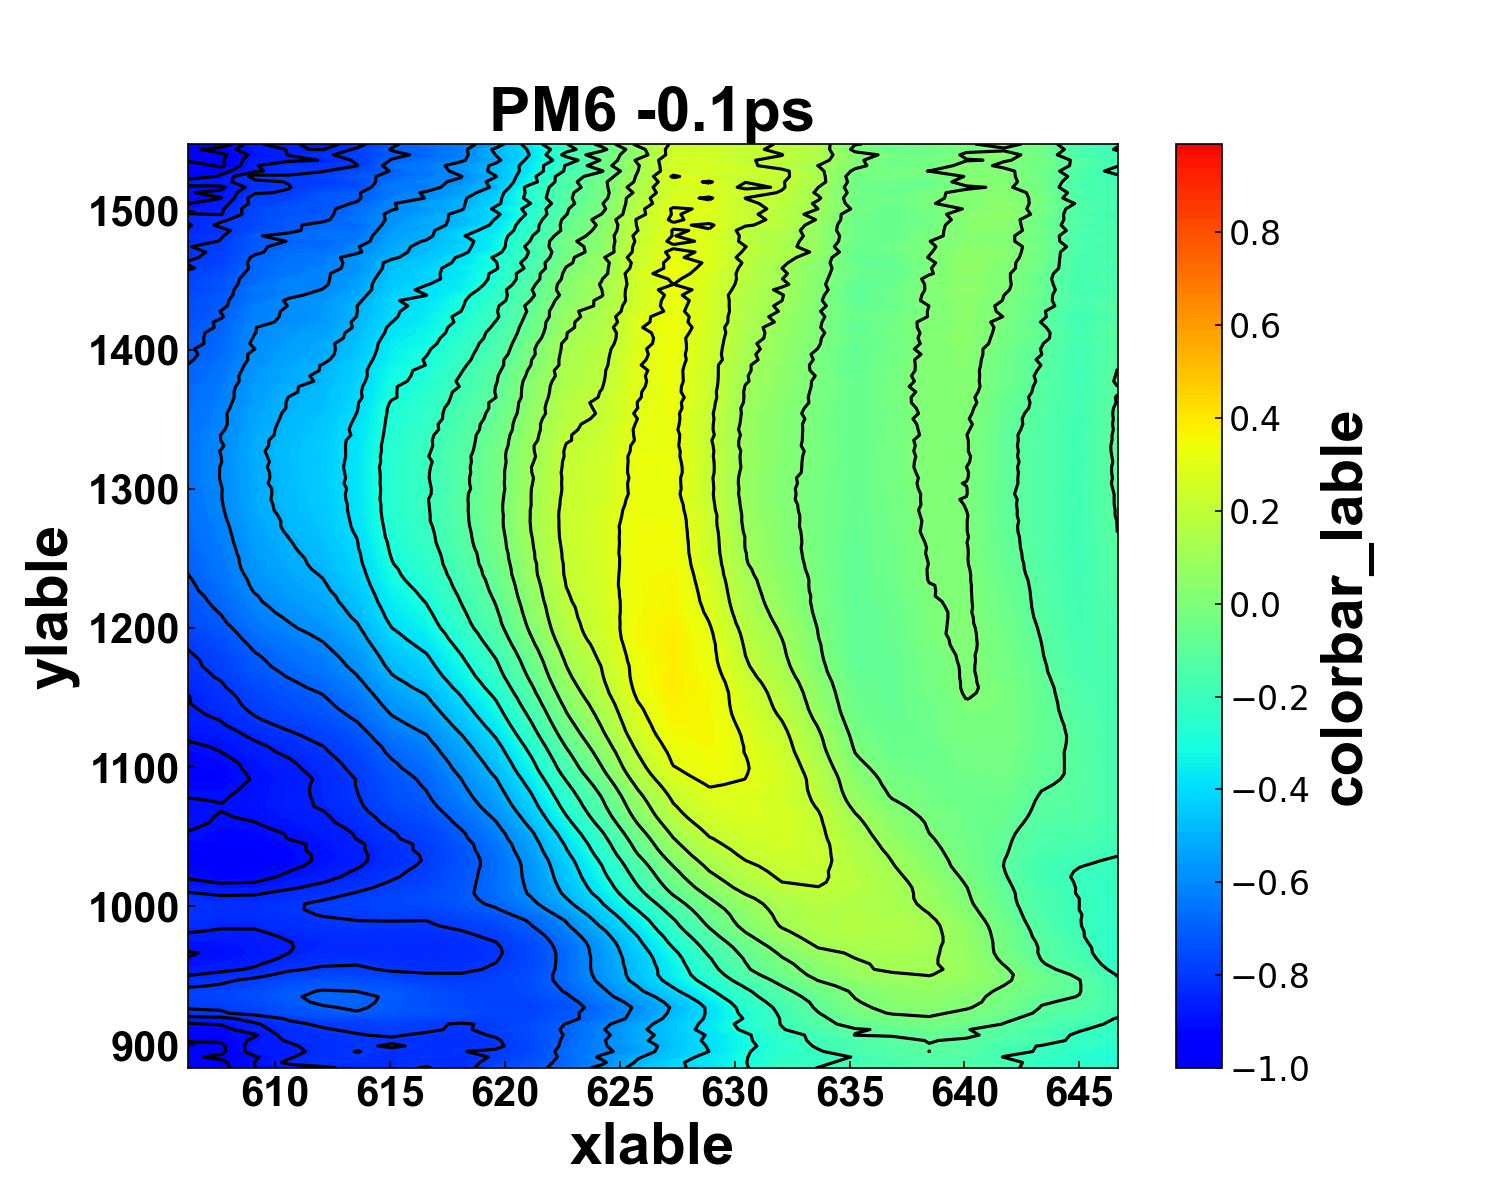

In [1]:
# drawing utils
%matplotlib notebook
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib import ticker, colors
from matplotlib import animation
from cycler import cycler
import os
import re
import numpy as np





#数据平均、截取

#colormap调整
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = colors.LinearSegmentedColormap.from_list(
        "trunc({n},{a:.2f},{b:.2f})".format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)),
    )
    return new_cmap

class plot2D:

    #输出图片的设置
    fig_title = 'title' #图片标题
    fig_save_path=r'./' #图片存储路径，默认在脚本所在目录
    fig_format = 'png' #输出格式，可以是pdf或者其他格式
    fig_dpi = 200 #图片dpi
    fig_size = (10,8) #画布大小
    
    #批量画图设置
    key_name = '' #关键词名
    key_list=['key_name'] #关键词列表
    file_list_average = False
    folder_path = './'#批量处理的时候数据所在文件夹路径
    file_list = []
    
    #画图风格设置
    colormap = 'jet' 
    color_level = np.arange(-1, 1, 0.01) #颜色色阶密度
    contour_line_level = [-1,-0.95,-0.9,-0.85,-0.8,-0.7,-0.6,-0.5,-0.4,-0.3,-0.2,-0.1,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]#轮廓线密度
    line_color = 'black' #
    line_style = 'solid'
    
    #坐标轴设置
    xtick_direction = 'in' #x轴刻线方向
    ytick_direction = 'in' #y轴刻线方向
    xlabel = 'xlable' #x轴标签
    ylabel = 'ylable' #y轴标签
    colorbar_lable = 'colorbar_lable' #colorbar标签
    xmin = 0 #x轴起始值
    xmax = 1 #x轴终止值
    ymin = 0 #y轴起始值
    ymax = 1 #y轴终止值
    
    #是否归一化
    normalization = False
    
    #数据读取设置
    file_path = ''#文件读取路径

#    file_dict = {}
    
    #字体字号设置
    font = 'Arial'
    title_fontsize = 30
    lable_fontsize = 28
    tick_fontsize = 20
    colorbar_tick_fontsize = 16
    fontweight = 'bold'
    
    def __init__(self):
        return None
    
    def parse_data(self,file_path = file_path, xmin = xmin, xmax = xmax,ymin = ymin, ymax = ymax,norm = normalization):
        rdata = np.loadtxt(self.file_path)
        ylist = rdata[0,1:]
        xlist = rdata[1:,0]
        xmin_index = np.searchsorted(xlist, self.xmin)
        ymax_index = np.searchsorted(xlist, self.xmax)
        xlist = xlist[xmin_index:xmax_index]
        ymin_index = np.searchsorted(ylist, self.ymin)
        ymax_index = np.searchsorted(ylist, self.ymax)
        ylist = ylist[ymin_index:ymax_index]
        data = rdata[xmin_index:xmax_index,ymin_index:ymax_index]
        if self.normalization == True:
            data_max = np.amax(np.absolute(data))
            data = np.transpose(data/data_max)*-1
        data_max = data.max()
        data_min = data.min()
        return ylist, xlist, data, data_max, data_min

    def parse_data_list(self, file_list = file_list, xmin = xmin, xmax = xmax,ymin = ymin, ymax = ymax, norm = normalization):
#        print('filelist = ', self.file_list)
        rdata = np.loadtxt(self.file_list[1])
        ylist = rdata[0,1:]
        xlist = rdata[1:,0]
        xmin_index = np.searchsorted(xlist, self.xmin)
        xmax_index = np.searchsorted(xlist, self.xmax)
        xlist = xlist[xmin_index:xmax_index]
        ymin_index = np.searchsorted(ylist, self.ymin)
        ymax_index = np.searchsorted(ylist, self.ymax)
        ylist = ylist[ymin_index:ymax_index]
        data = np.zeros([xmax_index - xmin_index,ymax_index - ymin_index])
        for file_path in self.file_list:
            rdata = np.loadtxt(file_path)
            
            data = rdata [xmin_index:xmax_index,ymin_index:ymax_index]+data
        data = data/len(self.file_list)
        if self.normalization == True:
            data_max=np.amax(np.absolute(data))
            data = np.transpose(data/data_max)*-1
        data_max = data.max()
        data_min = data.min()
        return ylist, xlist, data, data_max, data_min

    
    def FileNameParse(self):
        file_path_list = []
        print('folderpath=',self.folder_path)
        for maindir, subdie, file_name_list in os.walk(self.folder_path):
            for file_name in file_name_list:
                file_path_list.append(os.path.join(maindir, file_name))  
        DelayList = []
        start_index = 0
        end_index = 0
        FileDict = {}
        for file_path in file_path_list:
            for key in self.key_list:
                if key in file_path:
                    FileDict.setdefault(key,[]).append(file_path)
        return FileDict
    
    
    def plot_2d(self, key_name = key_name, data_list = False, file_list = None):
        plt.rcParams['xtick.direction'] = self.xtick_direction
        plt.rcParams['ytick.direction'] = self.ytick_direction 
        if data_list == False:
            if not os.path.exists(self.file_path):
                print('File not found, program stopped')
                os._exit(0)
            ylist, xlist, data, dmax, dmin = self.parse_data()
        else:
            ylist, xlist, data, dmax, dmin = self.parse_data_list()
        fig,ax=plt.subplots(figsize = self.fig_size)
        figtitle = self.fig_title +' '+ key_name
        plt.title(figtitle,fontproperties=self.font, fontsize=self.title_fontsize, fontweight=self.fontweight)
        plt.xlabel(self.xlabel,fontproperties=self.font, fontsize=self.lable_fontsize, fontweight=self.fontweight)
        plt.ylabel(self.ylabel,fontproperties=self.font, fontsize=self.lable_fontsize, fontweight=self.fontweight)
        plt.xticks(fontproperties=self.font, fontsize=self.tick_fontsize, fontweight=self.fontweight)
        plt.yticks(fontproperties=self.font, fontsize=self.tick_fontsize, fontweight=self.fontweight)
        cmap = plt.get_cmap(self.colormap)
        trunc_cmap = truncate_colormap(cmap, 0.1, 0.9,400)
        im = ax.contourf(xlist, ylist, data, levels=self.color_level, cmap=trunc_cmap, extend="neither")
        cbar = plt.colorbar(im,)
        cbar.set_label(self.colorbar_lable, font = self.font, fontsize = self.lable_fontsize, weight=self.fontweight)
        cbar.ax.tick_params(labelsize=self.colorbar_tick_fontsize)
        plt.contour(xlist, ylist, data, levels=self.contour_line_level, 
                    colors=self.line_color, linestyles=self.line_style)
        if not os.path.exists('./'+self.fig_save_path):
            os.makedirs('./'+self.fig_save_path)  
        figpath=r'./'+self.fig_save_path+r'/'+self.fig_title+'_'+self.key_name+'.'+self.fig_format
        fig.savefig(figpath, dpi=self.fig_dpi, format=self.fig_format)
        return 0
    
    def plot_list_2d(self): 
        file_dict = self.FileNameParse()
#        print('fildict=',file_dict)
        key_list=list(file_dict.keys())
        for key_name in key_list:
            self.key_name = key_name
            self.file_list = file_dict[key_name]
            self.plot_2d(key_name = key_name, data_list = True,file_list = file_dict[key_name] )
        return 0
            


if __name__ == '__main__':    
    def get_key_list(folder_path):
        file_path_list = []
        for maindir, subdie, file_name_list in os.walk(folder_path):
            for file_name in file_name_list:
                file_path_list.append(os.path.join(maindir, file_name)) 
        key_list = []
        start = 0
        end = 0 
        for i in range(len(file_path_list)):
            for j in range(len(file_path_list[i])):
                if file_path_list[i][j] == '_':
                    start = j
                elif file_path_list[i][j] == 'p':
                    end = j
            key_name = file_path_list[i][start+1:end+2]
            if key_name and key_name not in key_list:
                key_list.append(key_name)
        return key_list

    folder_path = r'C:\Users\30960\OneDrive\课题组\NIR\opv\2D\PM6\20220107-622pump-10uw'      
    a = plot2D()
    a.normalization = True
    a.folder_path = folder_path
    a.fig_title = re.split(r'\\',folder_path)[-2]
    a.fig_save_path =a.fig_title+'-'+re.findall(r'\\([0-9a-z-]+?)w',folder_path)[0]+'w'
    a.key_list = get_key_list(folder_path)
    a.xmin = 605
    a.xmax = 648
    a.ymin = 880
    a.ymax = 1550
    a.folder_path=r'C:\Users\30960\OneDrive\课题组\NIR\opv\2D\PM6\20220107-622pump-10uw'
    file_dict = a.FileNameParse()
    print('keylist=',a.key_list)
    a.plot_list_2d()


